In [1]:
!pip install seaborn scikit-learn xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
import io

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, classification_report

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression

sns.set(style="whitegrid")

In [42]:
!pip install seaborn scikit-learn xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
import io

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, classification_report

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression

sns.set(style="whitegrid")

In [2]:
uploaded = files.upload()

df = pd.read_csv(io.BytesIO(uploaded[list(uploaded.keys())[0]]))

print("Shape:", df.shape)
df.head()

Saving CaseCrew_DataVista_transactions.csv to CaseCrew_DataVista_transactions.csv
Shape: (100000, 41)


,Record_Id,Product_Id,Product_Name,Category,Store_Id,Region,Supplier_Id,Transaction_Date,Expiration_Date,Shelf_Life_Days,...,Selling_Price,Units_Sold,Units_Wasted,Waste_Pct,Revenue,Waste_Cost,Profit,Profit_Margin_Pct,Supplier_Score,Is_Promoted
0,1,BAK_DON_743,Donuts,Bakery,STORE_046,West,SUPPLIER_03,2024-09-25,2024-09-29,4,...,2.60,138,20,12.7,358.80,24.40,166.04,46.3,9,0
1,2,MEA_SAU_338,Sausages,Meat,STORE_030,Southwest,SUPPLIER_12,2023-04-14,2023-04-21,9,...,8.25,251,102,28.9,2070.75,426.36,595.21,28.7,6,0
2,3,BAK_BAG_799,Bagels,Bakery,STORE_035,Midwest,SUPPLIER_08,2024-10-25,2024-10-27,2,...,1.28,483,0,0.0,618.24,0.00,-405.72,-65.6,9,0
3,4,PHA_VAC_801,Vaccines,Pharmaceuticals,STORE_003,Midwest,SUPPLIER_11,2023-11-29,2024-02-17,87,...,209.56,477,0,0.0,99960.12,0.00,57988.89,58.0,6,0
4,5,REA_FRE_422,Fresh Pasta,Ready_to_Eat,STORE_042,West,SUPPLIER_15,2023-08-06,2023-08-09,4,...,5.28,391,0,0.0,2064.48,0.00,879.75,42.6,6,0


In [26]:
# Convert dates
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])
df['Expiration_Date'] = pd.to_datetime(df['Expiration_Date'])

# Features
df['Days_To_Expire'] = (df['Expiration_Date'] - df['Transaction_Date']).dt.days
df['Month'] = df['Transaction_Date'].dt.month

# Drop IDs safely
df = df.drop(columns=[col for col in ['Record_Id','Product_Id'] if col in df.columns])

df.head()

,Product_Name,Category,Store_Id,Region,Supplier_Id,Transaction_Date,Expiration_Date,Shelf_Life_Days,Days_Remaining_At_Purchase,Storage_Temp,...,Waste_Pct,Revenue,Waste_Cost,Profit,Profit_Margin_Pct,Supplier_Score,Is_Promoted,Days_To_Expire,High_Waste,Waste_Level
0,20,0,45,4,2,2024-09-25,2024-09-29,4,4,21.0,...,12.7,358.80,24.40,166.04,46.3,9,0,4,0,Low
1,49,5,29,3,11,2023-04-14,2023-04-21,9,7,0.7,...,28.9,2070.75,426.36,595.21,28.7,6,0,7,1,Medium
2,3,0,34,0,7,2024-10-25,2024-10-27,2,2,21.3,...,0.0,618.24,0.00,-405.72,-65.6,9,0,2,0,NaN
3,60,6,2,0,10,2023-11-29,2024-02-17,87,80,8.0,...,0.0,99960.12,0.00,57988.89,58.0,6,0,80,0,NaN
4,23,8,41,4,14,2023-08-06,2023-08-09,4,3,3.5,...,0.0,2064.48,0.00,879.75,42.6,6,0,3,0,NaN


In [27]:
# Target
df['High_Waste'] = (df['Waste_Pct'] > 20).astype(int)

# Cost impact
df['Waste_Cost'] = df['Units_Wasted'] * df['Cost_Price']

# Encode categorical
for col in df.select_dtypes(include=['object']).columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))


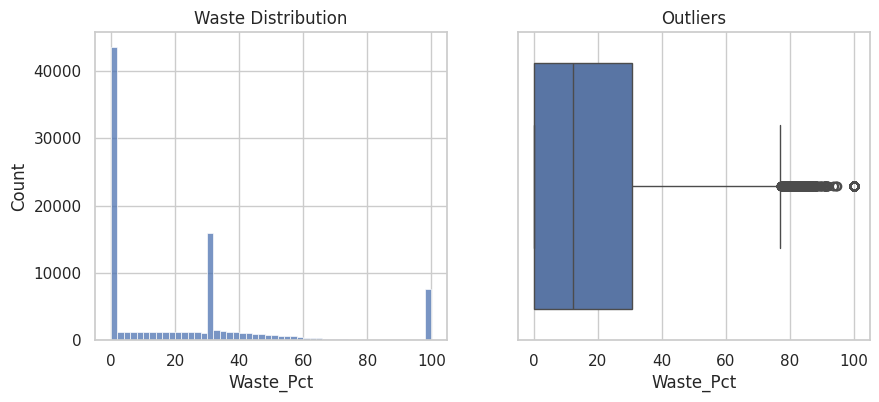

In [28]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df['Waste_Pct'], bins=50)
plt.title("Waste Distribution")

plt.subplot(1,2,2)
sns.boxplot(x=df['Waste_Pct'])
plt.title("Outliers")

plt.show()

/tmp/ipykernel_18383/560907500.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  expiry = df.groupby('Expiry_Group')['Waste_Pct'].mean().reset_index()


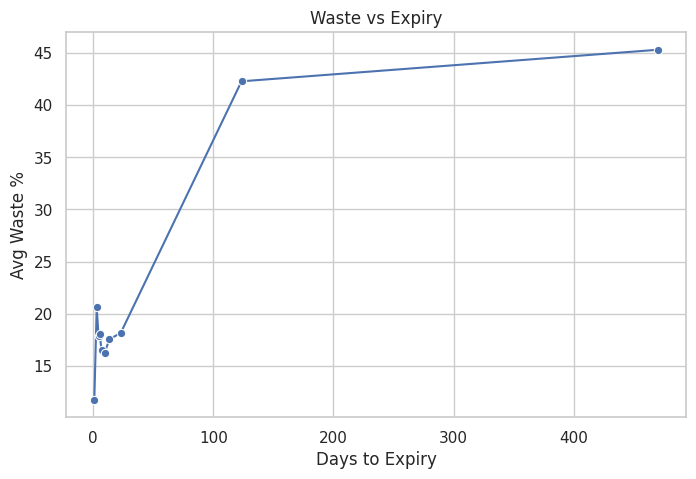

In [29]:
df['Expiry_Group'] = pd.qcut(df['Days_To_Expire'], 10, duplicates='drop')

expiry = df.groupby('Expiry_Group')['Waste_Pct'].mean().reset_index()

expiry['Days_Mid'] = expiry['Expiry_Group'].apply(lambda x: x.mid)

plt.figure(figsize=(8,5))
sns.lineplot(data=expiry, x='Days_Mid', y='Waste_Pct', marker='o')

plt.title("Waste vs Expiry")
plt.xlabel("Days to Expiry")
plt.ylabel("Avg Waste %")
plt.show()

/tmp/ipykernel_18383/105141255.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disc = df.groupby('Discount_Group')['Profit'].mean().reset_index()


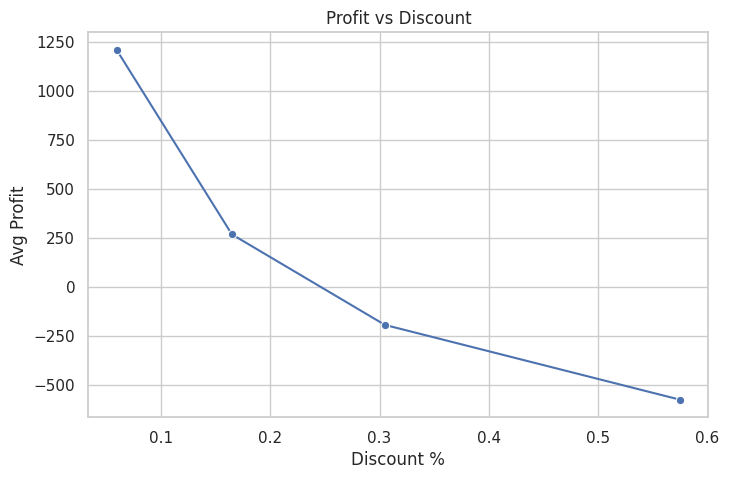

In [31]:
df['Discount_Group'] = pd.qcut(df['Discount_Pct'], 10, duplicates='drop')

disc = df.groupby('Discount_Group')['Profit'].mean().reset_index()

disc['Discount_Mid'] = disc['Discount_Group'].apply(lambda x: x.mid)

plt.figure(figsize=(8,5))
sns.lineplot(data=disc, x='Discount_Mid', y='Profit', marker='o')

plt.title("Profit vs Discount")
plt.xlabel("Discount %")
plt.ylabel("Avg Profit")
plt.show()

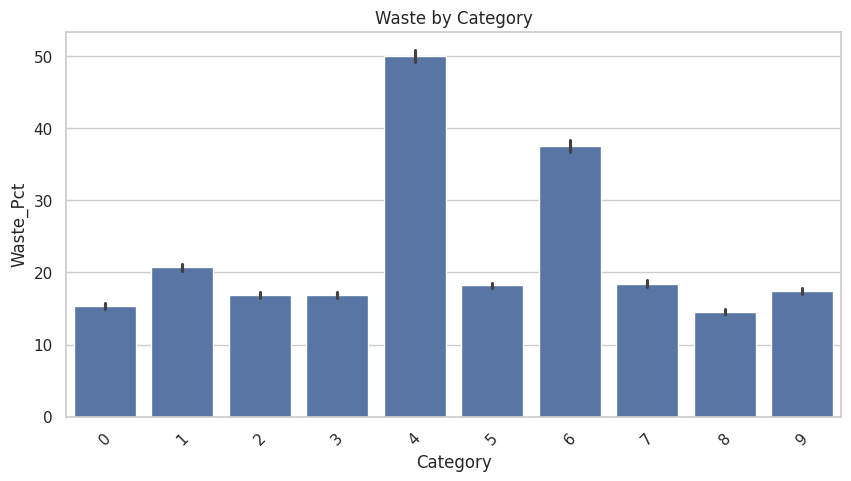

In [32]:
plt.figure(figsize=(10,5))
sns.barplot(x='Category', y='Waste_Pct', data=df)

plt.title("Waste by Category")
plt.xticks(rotation=45)
plt.show()

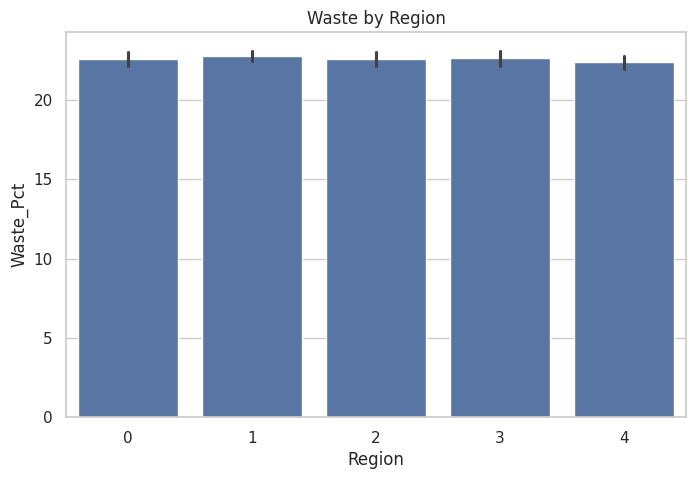

In [33]:
plt.figure(figsize=(8,5))
sns.barplot(x='Region', y='Waste_Pct', data=df)

plt.title("Waste by Region")
plt.show()

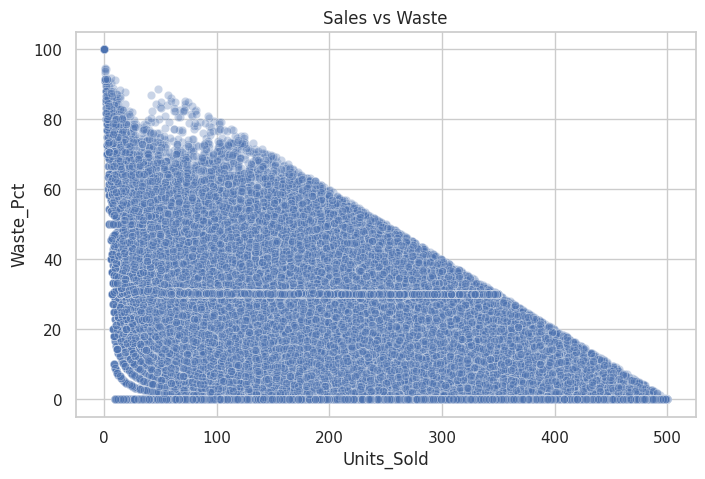

In [34]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Units_Sold', y='Waste_Pct', data=df, alpha=0.3)

plt.title("Sales vs Waste")
plt.show()

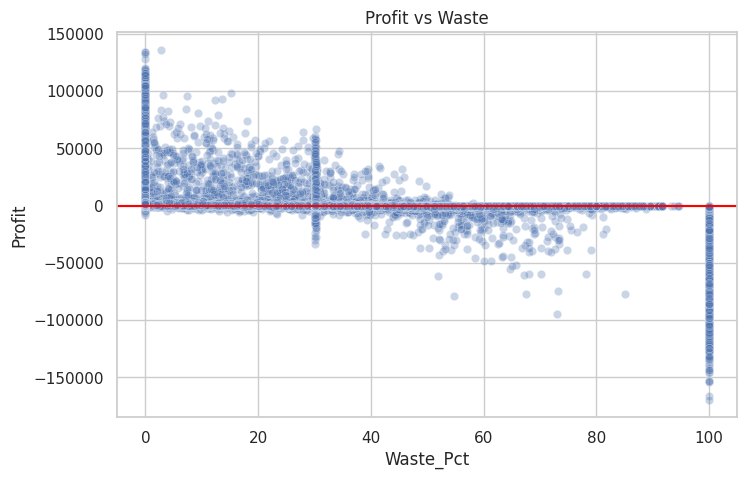

In [35]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Waste_Pct', y='Profit', data=df, alpha=0.3)

plt.axhline(0, color='red')
plt.title("Profit vs Waste")
plt.show()

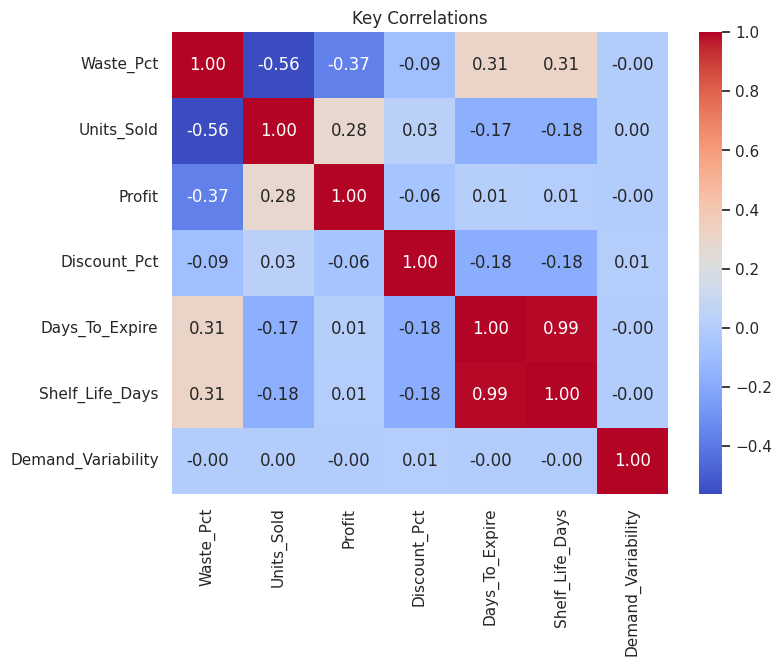

In [36]:
cols = ['Waste_Pct','Units_Sold','Profit','Discount_Pct',
        'Days_To_Expire','Shelf_Life_Days','Demand_Variability']

plt.figure(figsize=(8,6))
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Key Correlations")
plt.show()

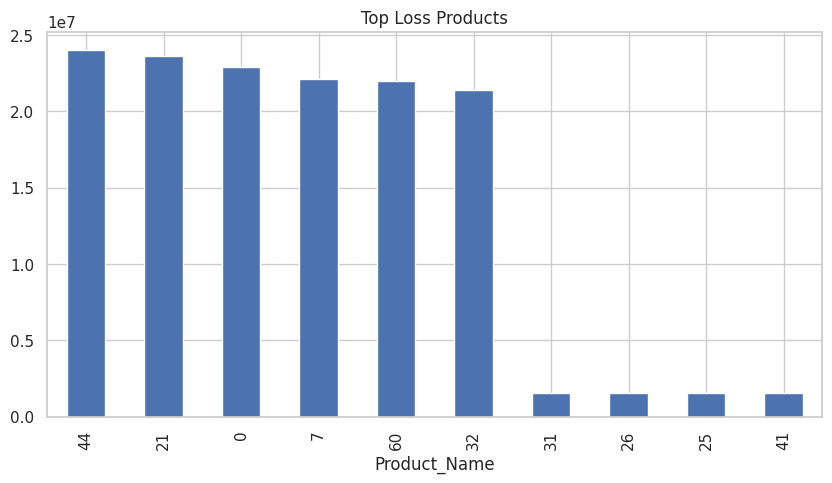

In [37]:
top_loss = df.groupby('Product_Name')['Waste_Cost'].sum().sort_values(ascending=False).head(10)

top_loss.plot(kind='bar', figsize=(10,5))
plt.title("Top Loss Products")
plt.show()

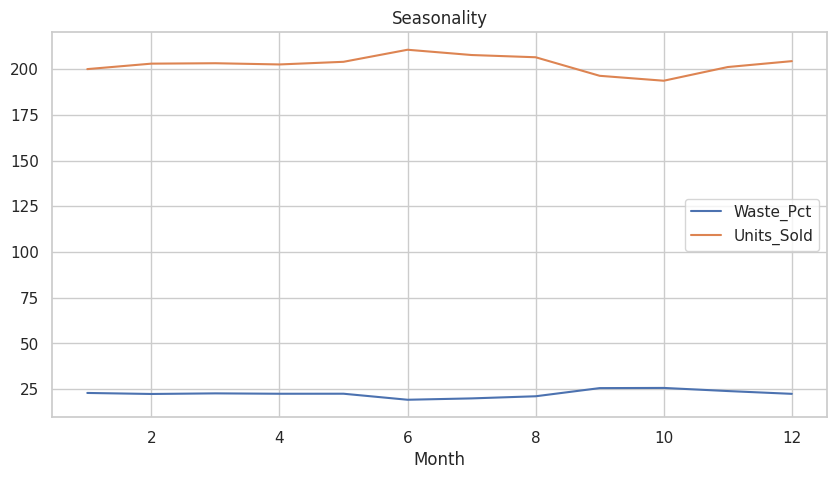

In [38]:
season = df.groupby('Month').agg({
    'Waste_Pct':'mean',
    'Units_Sold':'mean'
})

season.plot(figsize=(10,5))
plt.title("Seasonality")
plt.show()

In [39]:
print("KEY INSIGHTS:")
print("1. Waste increases near expiry.")
print("2. High discounts reduce profit.")
print("3. Some categories and regions perform worse.")
print("4. Low sales lead to higher waste.")
print("5. Waste directly impacts profit.")

KEY INSIGHTS:
1. Waste increases near expiry.
2. High discounts reduce profit.
3. Some categories and regions perform worse.
4. Low sales lead to higher waste.
5. Waste directly impacts profit.


In [78]:
df_ml = df.copy()

# Remove leakage + problematic + overly strong predictors
remove_cols = [
    'Units_Wasted',
    'Waste_Cost',
    'High_Waste',          # classification target (remove for regression)
    'Transaction_Date',
    'Expiration_Date',
    'Expiry_Group',
    'Discount_Group',

    # reduce overfitting
    'Shelf_Life_Days',
    'Days_Remaining_At_Purchase'
]

df_ml = df_ml.drop(columns=[col for col in remove_cols if col in df_ml.columns])

# Keep numeric only
df_ml = df_ml.select_dtypes(include=[np.number])

# Handle missing values
df_ml = df_ml.fillna(df_ml.median())

df_ml.head()

,Product_Name,Category,Store_Id,Region,Supplier_Id,Storage_Temp,Temp_Deviation,Base_Price,Cost_Price,Initial_Quantity,...,Discount_Pct,Selling_Price,Units_Sold,Waste_Pct,Revenue,Profit,Profit_Margin_Pct,Supplier_Score,Is_Promoted,Days_To_Expire
0,20,0,45,4,2,21.0,1.0,2.60,1.22,158,...,0.00,2.60,138,12.7,358.80,166.04,46.3,9,0,4
1,49,5,29,3,11,0.7,0.3,8.25,4.18,353,...,0.00,8.25,251,28.9,2070.75,595.21,28.7,6,0,7
2,3,0,34,0,7,21.3,1.3,4.12,2.12,483,...,0.69,1.28,483,0.0,618.24,-405.72,-65.6,9,0,2
3,60,6,2,0,10,8.0,3.0,209.56,87.99,477,...,0.00,209.56,477,0.0,99960.12,57988.89,58.0,6,0,80
4,23,8,41,4,14,3.5,0.5,6.86,3.03,391,...,0.23,5.28,391,0.0,2064.48,879.75,42.6,6,0,3


In [79]:
X = df_ml.drop(['Waste_Pct'], axis=1)
y = df['Waste_Pct']

In [80]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [81]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=150,
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=6, min_samples_leaf=5, min_samples_split=10,
                      n_estimators=150, random_state=42)

In [82]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

y_pred = model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2: 0.9337715859913494
RMSE: 7.4160132044416285


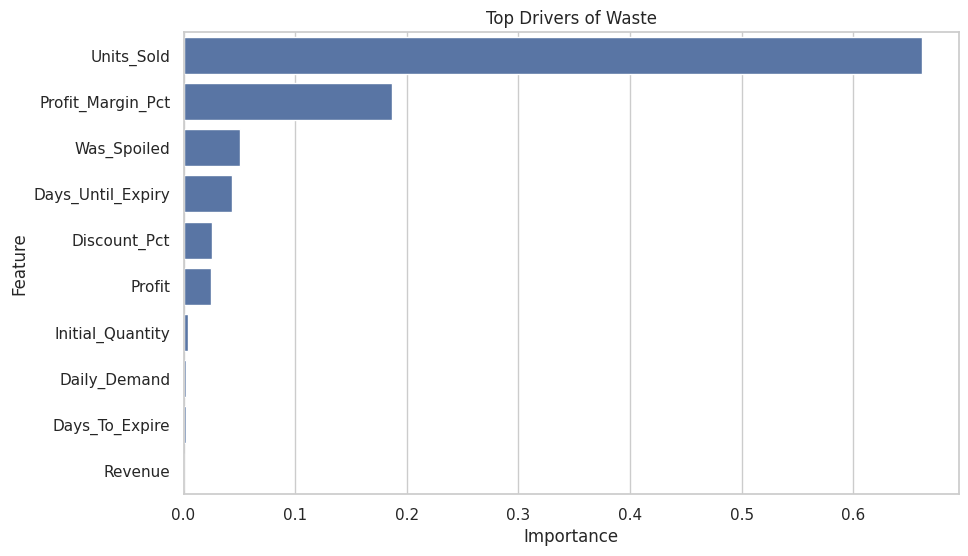

In [85]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

feat_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_df.head(10))
plt.title("Top Drivers of Waste")
plt.show()

In [86]:
df_clf = df.copy()

remove_cols = [
    'Units_Wasted',
    'Waste_Cost',
    'Transaction_Date',
    'Expiration_Date',
    'Expiry_Group',
    'Discount_Group',

    # reduce overfitting
    'Shelf_Life_Days',
    'Days_Remaining_At_Purchase'
]

df_clf = df_clf.drop(columns=[col for col in remove_cols if col in df_clf.columns])

df_clf = df_clf.select_dtypes(include=[np.number])
df_clf = df_clf.fillna(df_clf.median())

In [87]:
X = df_clf.drop(['High_Waste'], axis=1)
y = df_clf['High_Waste']

In [89]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [90]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(
    n_estimators=150,
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

clf.fit(X_train, y_train)

RandomForestClassifier(max_depth=6, min_samples_leaf=5, min_samples_split=10,
                       n_estimators=150, random_state=42)

In [92]:
df_clf = df.copy()

# REMOVE leakage columns (CRITICAL)
remove_cols = [
    'Units_Wasted',
    'Waste_Cost',
    'Transaction_Date',
    'Expiration_Date',
    'Expiry_Group',
    'Discount_Group',

    # THIS IS THE MAIN FIX
    'Waste_Pct'
]

df_clf = df_clf.drop(columns=[col for col in remove_cols if col in df_clf.columns])

# Keep numeric only
df_clf = df_clf.select_dtypes(include=[np.number])

# Handle missing
df_clf = df_clf.fillna(df_clf.median())

# Define X and y
X = df_clf.drop(['High_Waste'], axis=1)
y = df_clf['High_Waste']

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(
    n_estimators=150,
    max_depth=6,
    random_state=42
)

clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.94      0.94     10925
           1       0.93      0.92      0.92      9075

    accuracy                           0.93     20000
   macro avg       0.93      0.93      0.93     20000
weighted avg       0.93      0.93      0.93     20000

